# Full Agent — how is it doing?

Diagnostics for a PPO agent trained on the **full, faithful** game (`railroad_env`): mixed
terrain (plains/river/mountain at cost 1/2/3), disruption on both sides, 25 observation channels,
and a three-channel action space — PLACE, DISRUPT, and SKIP_DISRUPT.

Five things to look at, in the order they're usually worth checking:

1. **Training curves** — is score/win-rate still climbing, and are the PPO health metrics sane?
2. **Evaluation** — how does it actually do over many games, versus a random baseline?
3. **The board** — does it build *corridors between towns*, or just scatter track?
4. **Turn by turn** — what the network sees and picks on each individual decision.
5. **All 25 input channels** for the current position.

Run "Setup" once, then any section below it.

## Setup

In [10]:
%matplotlib inline
import glob
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "docs" else Path.cwd()))

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from railroad_env import RailroadGymEnv
from railroad_env.game_state import GameState
from training.agent_model import RailroadUNet
from training.ppo import _decode_action
from training.simulator import GameSimulator

CHANNEL_NAMES = [
    "terrain: plains", "terrain: river", "terrain: mountain",
    "enemy track present", "own track present",
    "enemy tracks in region /10", "own tracks in region /10", "region size (norm)",
    "enemy active-conn tracks /10", "own active-conn tracks /10",
] + [f"town {i} route guide" for i in range(GameState.NUM_TOWN_CHANNELS)] + [
    "region instability /4", "region inked", "active connection",
    "towns", "score gap /10k (flat)", "turn /100 (flat)",
    # 28-37: derived channels, railroad_env/features.py
    "connections through cell /10", "own income in region /20", "enemy income in region /20",
    "tanh(score gap /300) (flat)", "tanh(income gap /30) (flat)", "region has a town (un-inkable)",
    "cheapest-completion corridors /5", "1 / completion cost", "reachable connection share (flat)",
    "opponent instability in region /4",
]
assert len(CHANNEL_NAMES) == GameState.NUM_CHANNELS

# Defaults to the newest non-lite checkpoint; set a path explicitly to pin one.
_candidates = [p for p in glob.glob("checkpoints/*.pt") if "lite" not in p and "distil" not in p]
CHECKPOINT_PATH = max(_candidates, key=lambda p: Path(p).stat().st_mtime, default=None)

EPSILON = 0.0          # 0 = greedy/deployment behaviour, which is how you'd actually run it
GRID_HEIGHT = None     # None = authentic random size (h 14..20)
MAX_TURNS = 30         # match whatever the checkpoint was trained with
OPPONENT_KWARGS = {"wait_probability": 0.5, "disrupt_probability": 0.5}
SEED = 0

device = "cuda" if torch.cuda.is_available() else "cpu"

if CHECKPOINT_PATH is not None:
    blob = torch.load(CHECKPOINT_PATH, map_location=device)
    model = RailroadUNet(**blob["model_kwargs"]).to(device)
    model.load_state_dict(blob["model_state_dict"])
    print(f"Loaded {CHECKPOINT_PATH}  (iteration {blob.get('iteration', '?')})")
    print(f"  {blob['model_kwargs']}")
else:
    model = RailroadUNet(in_channels=GameState.NUM_CHANNELS, policy_channels=3).to(device)
    print("No checkpoint found - using a random-init model")
model.eval()
ALLOW_SKIP = model.head.out_channels == 3
print(f"{sum(p.numel() for p in model.parameters()):,} parameters on {device}"
      f"  |  skip-disrupt {'enabled' if ALLOW_SKIP else 'disabled'}")


Loaded checkpoints/20260910-224257_iter800.pt  (iteration 800)
  {'in_channels': 28, 'policy_channels': 3, 'base_channels': 64, 'value_hidden': 256}
2,189,380 parameters on cuda  |  skip-disrupt enabled


## Helpers

In [11]:
def make_env(seed):
    return RailroadGymEnv(grid_height=GRID_HEIGHT, max_turns=MAX_TURNS,
                          opponent_strategy="random", opponent_kwargs=OPPONENT_KWARGS, seed=seed)


def greedy_action(model, sim, epsilon=0.0, rng=None):
    """One forward pass -> (action, policy probabilities (C,H,W), value, chosen canvas cell)."""
    state, mask = sim.get_encoded_state(), sim.get_action_mask()
    with torch.no_grad():
        x = torch.from_numpy(state).unsqueeze(0).to(device)
        m = torch.from_numpy(mask).unsqueeze(0).to(device)
        logits, value = model(x, m)
        flat = logits.flatten(1)
        probs = torch.softmax(flat, dim=1).view_as(logits)[0].cpu().numpy()
        if rng is not None and rng.random_sample() < epsilon:
            index = int(torch.distributions.Categorical(logits=flat).sample().item())
        else:
            index = int(torch.argmax(flat, dim=1).item())
    action = _decode_action(index, mask.shape, sim.pad_offsets)
    channel, remainder = divmod(index, mask.shape[1] * mask.shape[2])
    row, col = divmod(remainder, mask.shape[2])
    return action, probs, float(value.item()), (channel, row, col)


def play_game(model, seed, epsilon=0.0):
    """Play one full game and return (finished simulator, action-kind counts)."""
    from collections import Counter
    rng = np.random.RandomState(seed)
    env = make_env(seed); env.reset()
    sim = GameSimulator.from_env(env, allow_skip_disrupt=ALLOW_SKIP)
    kinds = Counter()
    while not sim.is_game_over():
        action, _, _, _ = greedy_action(model, sim, epsilon, rng)
        kinds[action[0]] += 1
        sim.apply(action)
    return sim, kinds


def play_random_game(seed):
    """Same game, but player 0 picks uniformly among legal actions - the baseline to beat."""
    rng = np.random.RandomState(seed)
    env = make_env(seed); env.reset()
    sim = GameSimulator.from_env(env, allow_skip_disrupt=ALLOW_SKIP)
    while not sim.is_game_over():
        legal = sim.get_legal_actions()
        sim.apply(legal[rng.randint(len(legal))])
    return sim


def game_stats(sim, kinds=None):
    gs = sim.game_state
    return {
        "score": gs.scores[0], "opponent": gs.scores[1],
        "margin": gs.scores[0] - gs.scores[1], "won": gs.scores[0] > gs.scores[1],
        "connections": sum(len(t.paths) for t in gs.towns),
        "wanted": sum(len(t.desired_connections) for t in gs.towns),
        "inked": sum(1 for z in gs.zones if z.inked),
        "disrupts": (kinds or {}).get("DISRUPT", 0),
        "skips": (kinds or {}).get("SKIP_DISRUPT", 0),
    }


## 1. Training curves

Reads the TensorBoard scalars straight off disk. `player0_score` and `win_rate` are what you
actually care about; the rest are PPO health checks — `approx_kl` should stay small (roughly
< 0.1) and *not trend upward*, `clip_frac` ideally sits around 0.1-0.2, and `entropy` collapsing
to 0 would mean the policy has stopped exploring entirely.

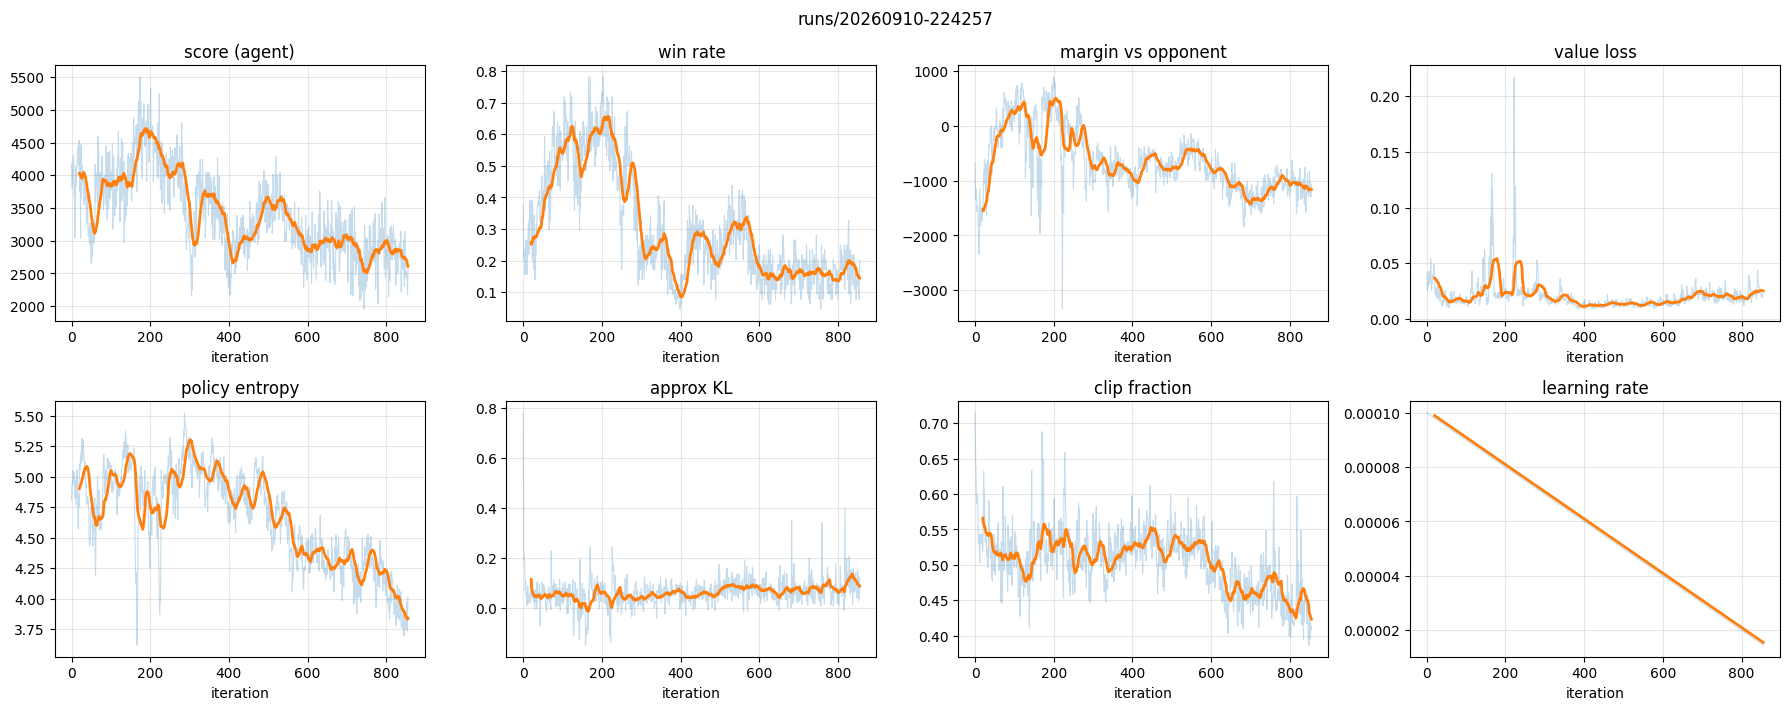

last-10-iteration averages:
  self_play/player0_score       2511.0813
  self_play/win_rate               0.1281
  self_play/score_margin       -1166.9281
  train/value_loss                 0.0223
  train/entropy                    3.8500
  train/approx_kl                  0.0744
  train/clip_frac                  0.4050
  train/learning_rate              0.0000


In [12]:
from tensorboard.backend.event_processing import event_accumulator

_runs = [p for p in glob.glob("runs/*")
         if "lite" not in p and "distil" not in p and Path(p).is_dir()]
RUN_DIR = max(_runs, key=lambda p: Path(p).stat().st_mtime, default=None)

if RUN_DIR is None:
    print("No full-game run directory found under runs/")
else:
    ea = event_accumulator.EventAccumulator(RUN_DIR, size_guidance={"scalars": 0})
    ea.Reload()
    available = set(ea.Tags()["scalars"])
    panels = [
        ("self_play/player0_score", "score (agent)"),
        ("self_play/win_rate", "win rate"),
        ("self_play/score_margin", "margin vs opponent"),
        ("train/value_loss", "value loss"),
        ("train/entropy", "policy entropy"),
        ("train/approx_kl", "approx KL"),
        ("train/clip_frac", "clip fraction"),
        ("train/learning_rate", "learning rate"),
    ]
    panels = [(t, lbl) for t, lbl in panels if t in available]

    rows = (len(panels) + 3) // 4
    fig, axes = plt.subplots(rows, 4, figsize=(18, 3.6 * rows))
    for ax, (tag, label) in zip(np.atleast_1d(axes).flat, panels):
        events = ea.Scalars(tag)
        steps = [e.step for e in events]
        vals = np.array([e.value for e in events])
        ax.plot(steps, vals, alpha=0.25, lw=0.8)
        if len(vals) >= 20:
            w = max(5, len(vals) // 40)
            ax.plot(steps[w - 1:], np.convolve(vals, np.ones(w) / w, mode="valid"), lw=2)
        ax.set_title(label); ax.set_xlabel("iteration"); ax.grid(alpha=0.3)
    for ax in list(np.atleast_1d(axes).flat)[len(panels):]:
        ax.axis("off")
    fig.suptitle(RUN_DIR, fontsize=12)
    plt.tight_layout(); plt.show()

    print("last-10-iteration averages:")
    for tag, _ in panels:
        print(f"  {tag:28s} {np.mean([e.value for e in ea.Scalars(tag)][-10:]):10.4f}")


## 2. Evaluation

Plays `N_GAMES` complete games greedily (`EPSILON = 0`) on fresh random maps, and the *same*
maps with a random player, so the comparison controls for map difficulty.

agent            score     94.2 +-   134.0   margin    +88.1   win rate 0.50   connections 25/450 (6%)   scored 0 in 10/20
random baseline  score      3.2 +-    10.1   margin     +1.9   win rate 0.10   connections 2/450 (0%)   scored 0 in 18/20

disruption: chose DISRUPT 353 times, SKIP_DISRUPT 247 times (41% declined)   regions inked 48


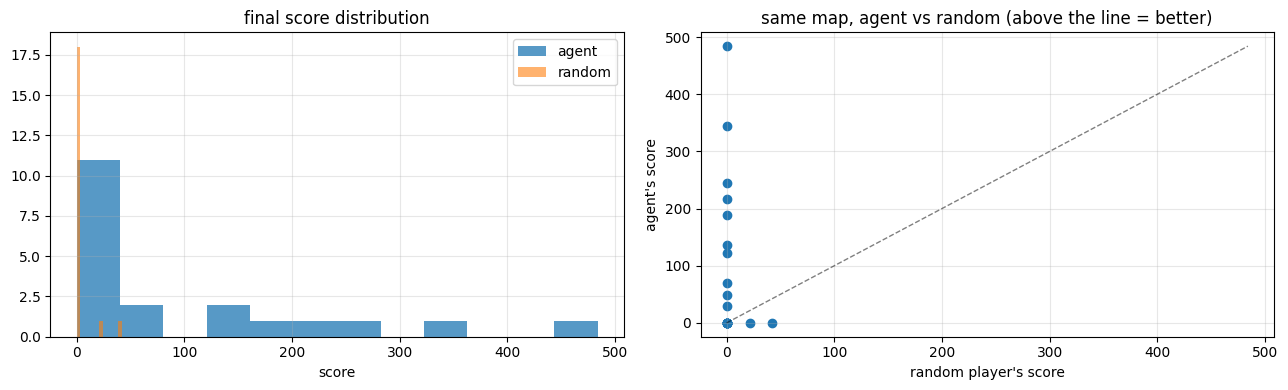

In [13]:
N_GAMES = 20

agent = [game_stats(*play_game(model, seed=1000 + i, epsilon=EPSILON)) for i in range(N_GAMES)]
random_baseline = [game_stats(play_random_game(seed=1000 + i)) for i in range(N_GAMES)]

def summarize(name, rows):
    score = np.array([r["score"] for r in rows])
    made, wanted = sum(r["connections"] for r in rows), sum(r["wanted"] for r in rows)
    print(f"{name:16s} score {score.mean():8.1f} +- {score.std():7.1f}   "
          f"margin {np.mean([r['margin'] for r in rows]):+8.1f}   "
          f"win rate {np.mean([r['won'] for r in rows]):.2f}   "
          f"connections {made}/{wanted} ({made / max(1, wanted):.0%})   "
          f"scored 0 in {(score == 0).sum()}/{len(rows)}")

summarize("agent", agent)
summarize("random baseline", random_baseline)

d, s_ = sum(r["disrupts"] for r in agent), sum(r["skips"] for r in agent)
print(f"\ndisruption: chose DISRUPT {d} times, SKIP_DISRUPT {s_} times "
      f"({s_ / max(1, d + s_):.0%} declined)   regions inked {sum(r['inked'] for r in agent)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist([r["score"] for r in agent], bins=12, alpha=0.75, label="agent")
axes[0].hist([r["score"] for r in random_baseline], bins=12, alpha=0.6, label="random")
axes[0].set_title("final score distribution"); axes[0].set_xlabel("score"); axes[0].legend()

pairs = np.array([[a["score"], b["score"]] for a, b in zip(agent, random_baseline)])
axes[1].scatter(pairs[:, 1], pairs[:, 0])
lim = max(1, pairs.max())
axes[1].plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5)
axes[1].set_xlabel("random player's score"); axes[1].set_ylabel("agent's score")
axes[1].set_title("same map, agent vs random (above the line = better)")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### Performance by map size

The map is a different size every game (height 14-20), and bigger maps carry more towns, each
wanting more connections. Splitting the evaluation by size shows whether the agent handles that
range evenly or only does well on part of it.

     map  towns  games  mean score    connections
   21x14      5      2         336     9/19     ( 47%)
   23x15      6      3         177     5/38     ( 13%)
   24x16      7      2          92     2/32     (  6%)
   26x17      8      6          26     6/117    (  5%)
   27x18      9      3           0     0/76     (  0%)
   29x19     11      2         172     3/79     (  4%)
   30x20     12      2           0     0/89     (  0%)


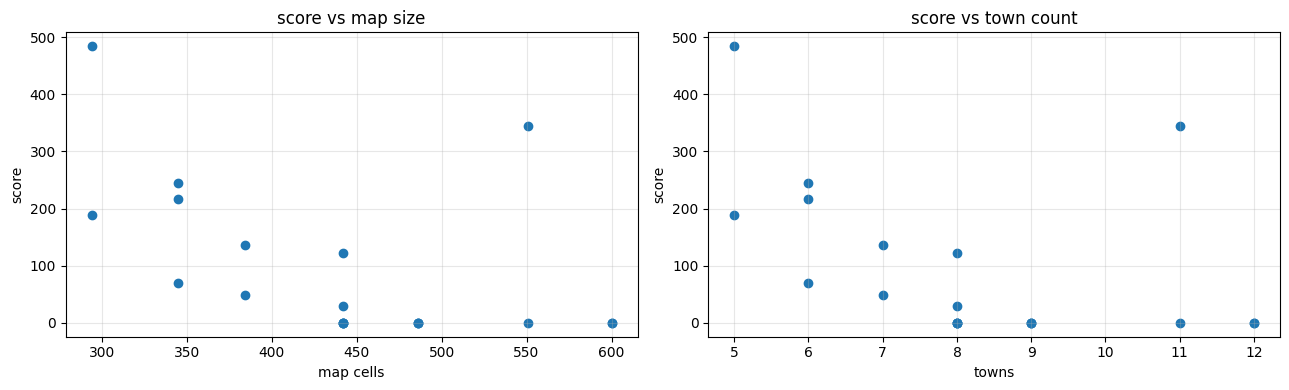


10/20 games scored nothing. Their closest desired pair was 5.2 cells apart on average.


In [14]:
rows = []
for i in range(N_GAMES):
    sim, kinds = play_game(model, seed=1000 + i, epsilon=EPSILON)
    gs = sim.game_state
    closest = min((abs(t.coord[0] - o.coord[0]) + abs(t.coord[1] - o.coord[1])
                   for t in gs.towns for o in t.desired_connections), default=np.nan)
    rows.append({"cells": gs.width * gs.height, "size": f"{gs.width}x{gs.height}",
                 "towns": len(gs.towns), "score": gs.scores[0],
                 "connections": sum(len(t.paths) for t in gs.towns),
                 "wanted": sum(len(t.desired_connections) for t in gs.towns),
                 "closest_pair": closest})

by_size = {}
for r in rows:
    by_size.setdefault(r["size"], []).append(r)

print(f"{'map':>8} {'towns':>6} {'games':>6} {'mean score':>11} {'connections':>14}")
for size in sorted(by_size, key=lambda s: by_size[s][0]["cells"]):
    g = by_size[size]
    made, wanted = sum(r["connections"] for r in g), sum(r["wanted"] for r in g)
    print(f"{size:>8} {g[0]['towns']:>6} {len(g):>6} {np.mean([r['score'] for r in g]):>11.0f} "
          f"{made:>5}/{wanted:<6} ({made / max(1, wanted):>4.0%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].scatter([r["cells"] for r in rows], [r["score"] for r in rows])
axes[0].set_xlabel("map cells"); axes[0].set_ylabel("score"); axes[0].set_title("score vs map size")
axes[1].scatter([r["towns"] for r in rows], [r["score"] for r in rows])
axes[1].set_xlabel("towns"); axes[1].set_ylabel("score"); axes[1].set_title("score vs town count")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

zeros = [r for r in rows if r["score"] == 0]
if zeros:
    print(f"\n{len(zeros)}/{len(rows)} games scored nothing. Their closest desired pair was "
          f"{np.nanmean([r['closest_pair'] for r in zeros]):.1f} cells apart on average.")


## 3. What the board actually looks like

The single most informative check: does the agent lay **corridors between towns**, or spray
track around? Cells on an active connection are outlined — those are the ones paying out every
turn. Inked-out regions (destroyed by disruption) are shown in dark grey.

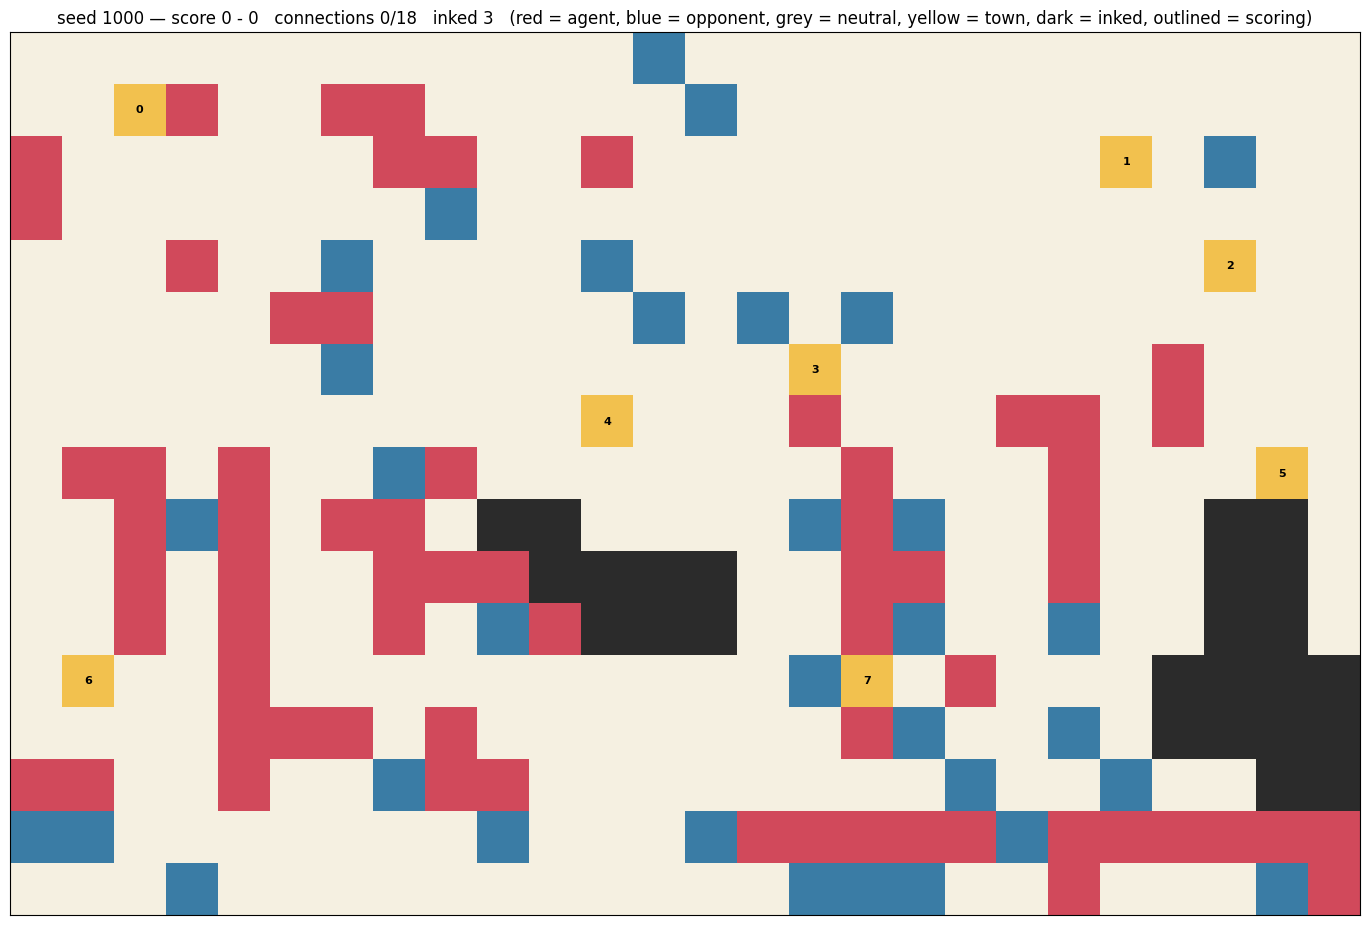

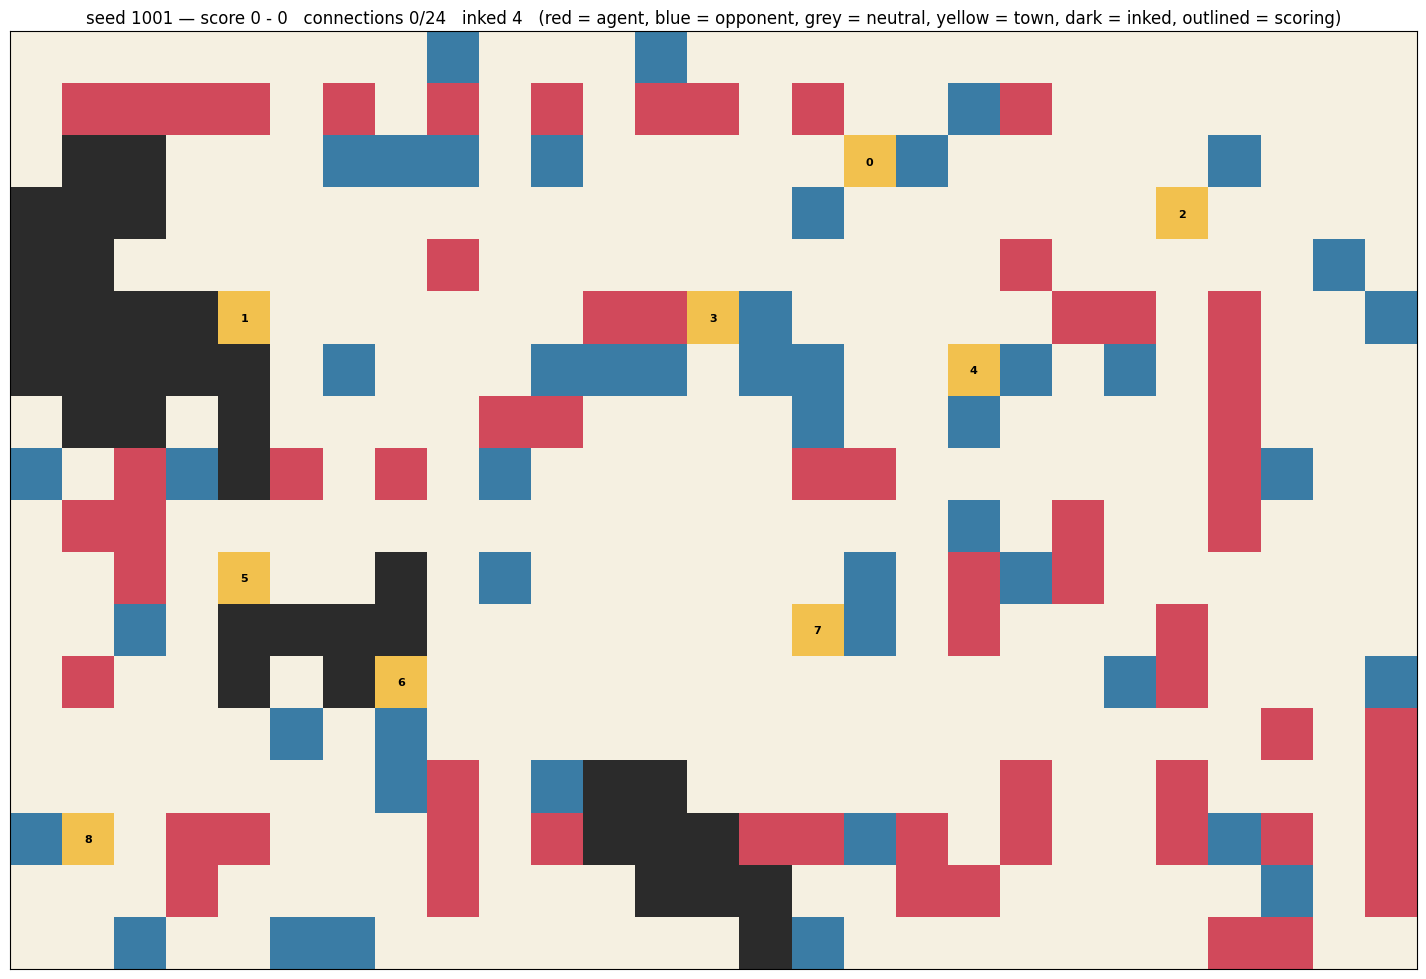

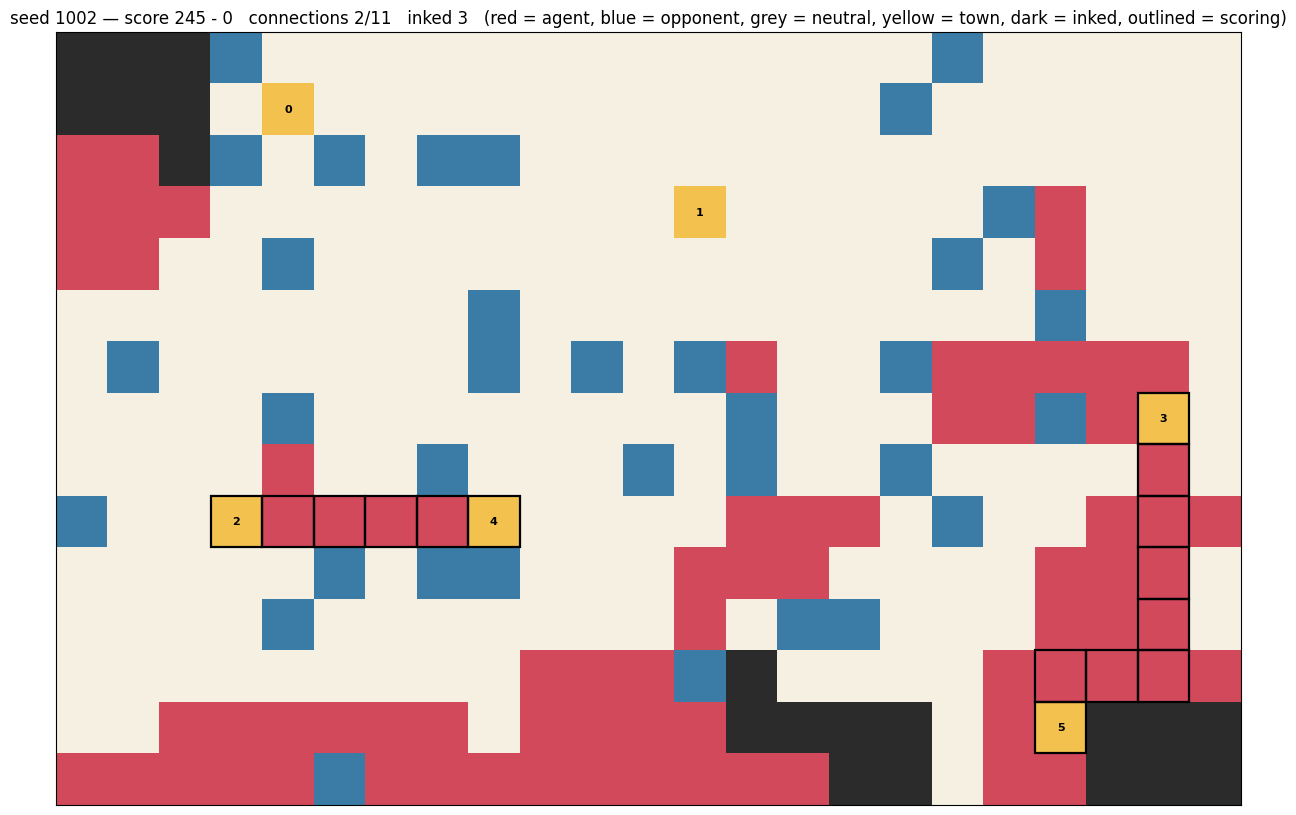

In [15]:
def plot_board(sim, title=""):
    gs = sim.game_state
    board = np.zeros((gs.height, gs.width))
    inked = {z.id for z in gs.zones if z.inked}
    for y in range(gs.height):
        for x in range(gs.width):
            if gs.get_region(x, y) in inked:
                board[y, x] = 5
    board[gs.tracks == 0] = 1   # agent
    board[gs.tracks == 1] = 2   # opponent
    board[gs.tracks == 2] = 3   # neutral
    for t in gs.towns:
        board[t.coord[1], t.coord[0]] = 4

    cmap = ListedColormap(["#f5f0e1", "#d1495b", "#3a7ca5", "#8d99ae", "#f2c14e", "#2b2b2b"])
    fig, ax = plt.subplots(figsize=(min(16, gs.width * 0.55), min(11, gs.height * 0.55)))
    ax.imshow(board, cmap=cmap, vmin=0, vmax=5)

    for (x, y) in gs.calculate_active_connections():
        ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, fill=False, edgecolor="black", lw=1.6))
    for t in gs.towns:
        ax.text(t.coord[0], t.coord[1], str(t.id), ha="center", va="center", fontsize=8, weight="bold")

    made = sum(len(t.paths) for t in gs.towns)
    wanted = sum(len(t.desired_connections) for t in gs.towns)
    ax.set_title(
        f"{title}score {gs.scores[0]} - {gs.scores[1]}   connections {made}/{wanted}   "
        f"inked {len(inked)}   (red = agent, blue = opponent, grey = neutral, yellow = town, "
        f"dark = inked, outlined = scoring)"
    )
    ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()


for seed in (1000, 1001, 1002):
    sim, _ = play_game(model, seed=seed, epsilon=EPSILON)
    plot_board(sim, title=f"seed {seed} — ")


## 4. Turn by turn

Re-run the cell below repeatedly — each run advances one turn (placements until the 3-point paint
budget is spent, then the disrupt decision) and plots the policy heatmaps for every individual
decision, so you can see how each pick reacts to the one before it.

In [16]:
# (Re-)start a game to step through.
step_env = make_env(SEED); step_env.reset()
step_sim = GameSimulator.from_env(step_env, allow_skip_disrupt=ALLOW_SKIP)
step_rng = np.random.RandomState(SEED)

gs = step_sim.game_state
print(f"Map {gs.width}x{gs.height}, {len(gs.towns)} towns, {gs.max_turns} turns, "
      f"{len(gs.zones)} regions")
print(f"{'id':>3}  {'(x, y)':>8}  wants")
for t in gs.towns:
    print(f"{t.id:>3}  ({t.coord[0]:>2}, {t.coord[1]:>2})  -> "
          f"{', '.join(str(o.id) for o in t.desired_connections) or '(none)'}")


Map 27x18, 9 towns, 30 turns, 54 regions
 id    (x, y)  wants
  0  (12,  2)  -> 5, 6, 8
  1  ( 3,  3)  -> 0
  2  (15,  4)  -> 1, 7, 8
  3  ( 9,  5)  -> 1, 2, 4
  4  (21,  6)  -> 0, 6, 7
  5  (16,  9)  -> 1, 4, 6
  6  ( 8, 11)  -> 1, 2
  7  (21, 10)  -> 3, 6, 8
  8  ( 5, 13)  -> 1, 3, 5


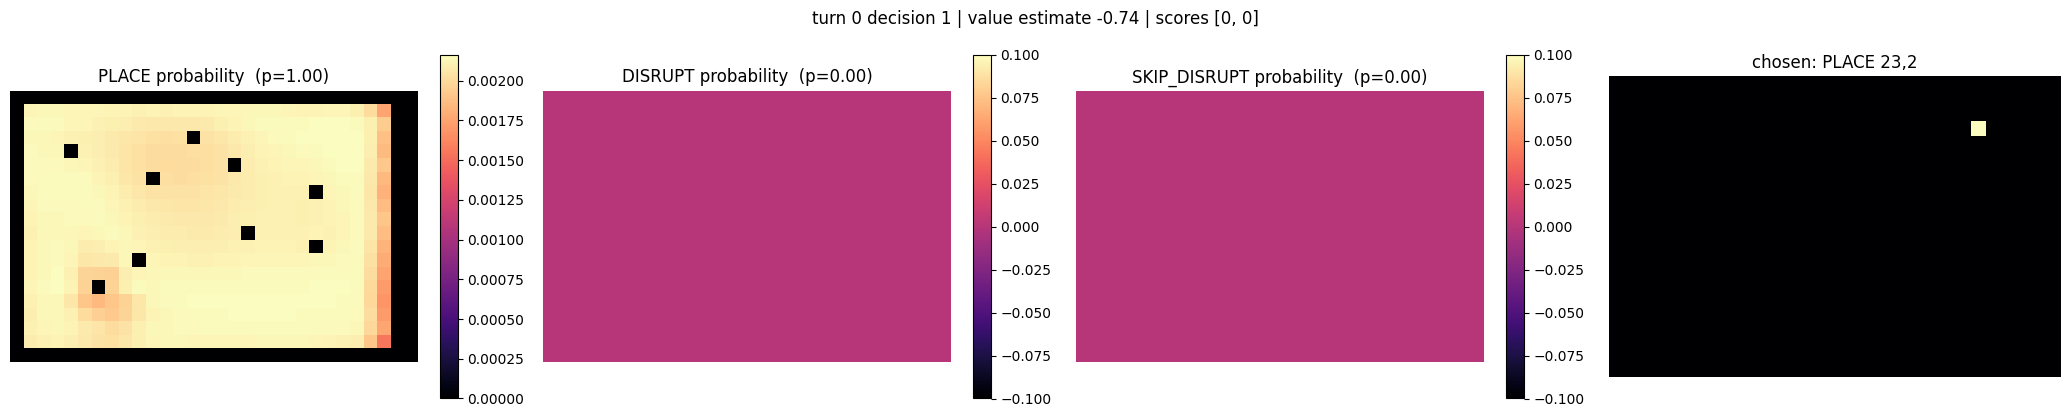

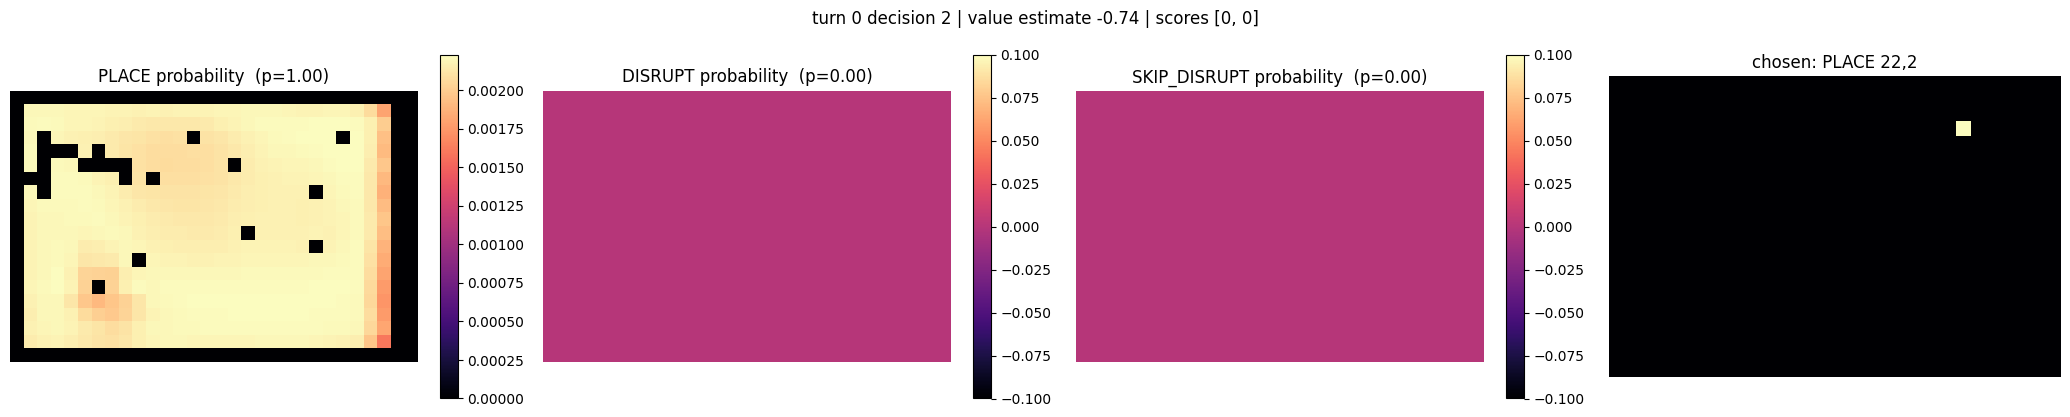

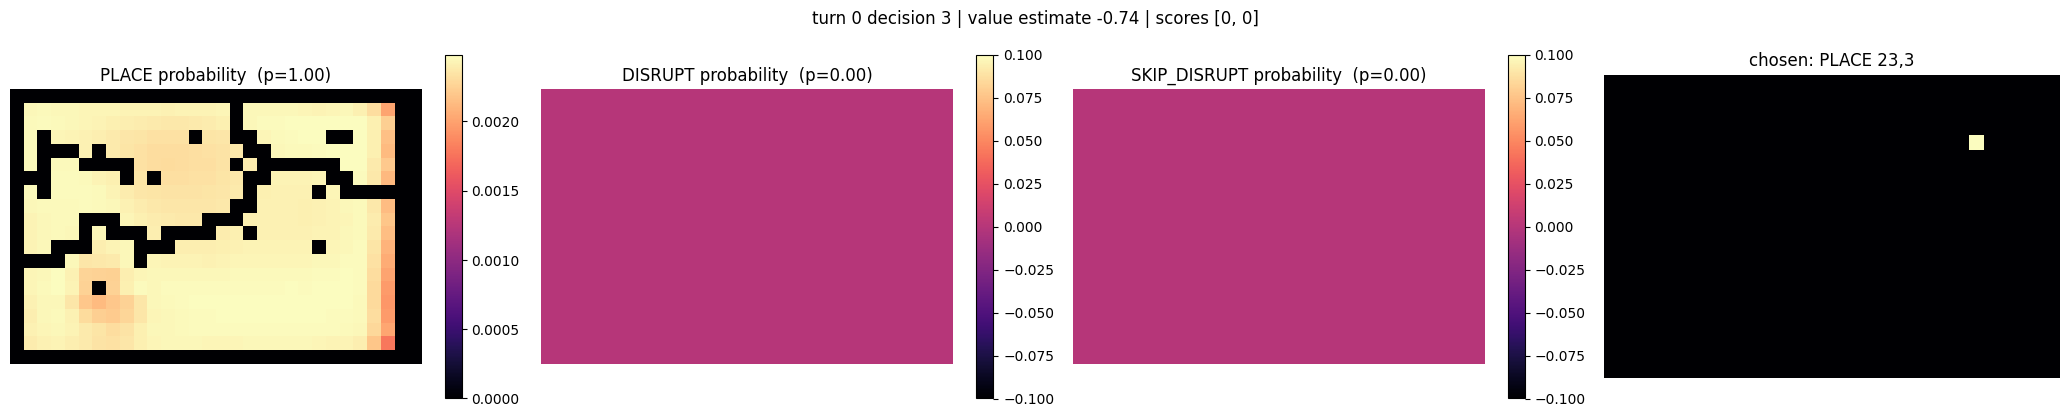

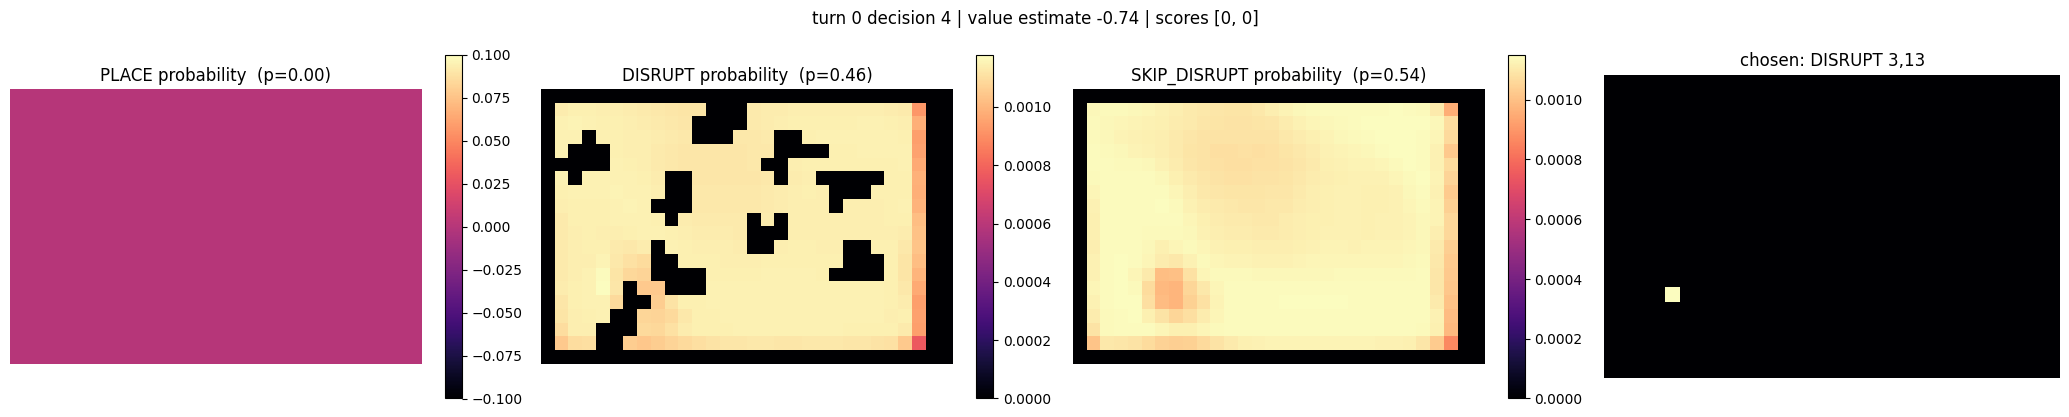

Turn 1/30 | score 0 - 0 | connections 0 | inked 0


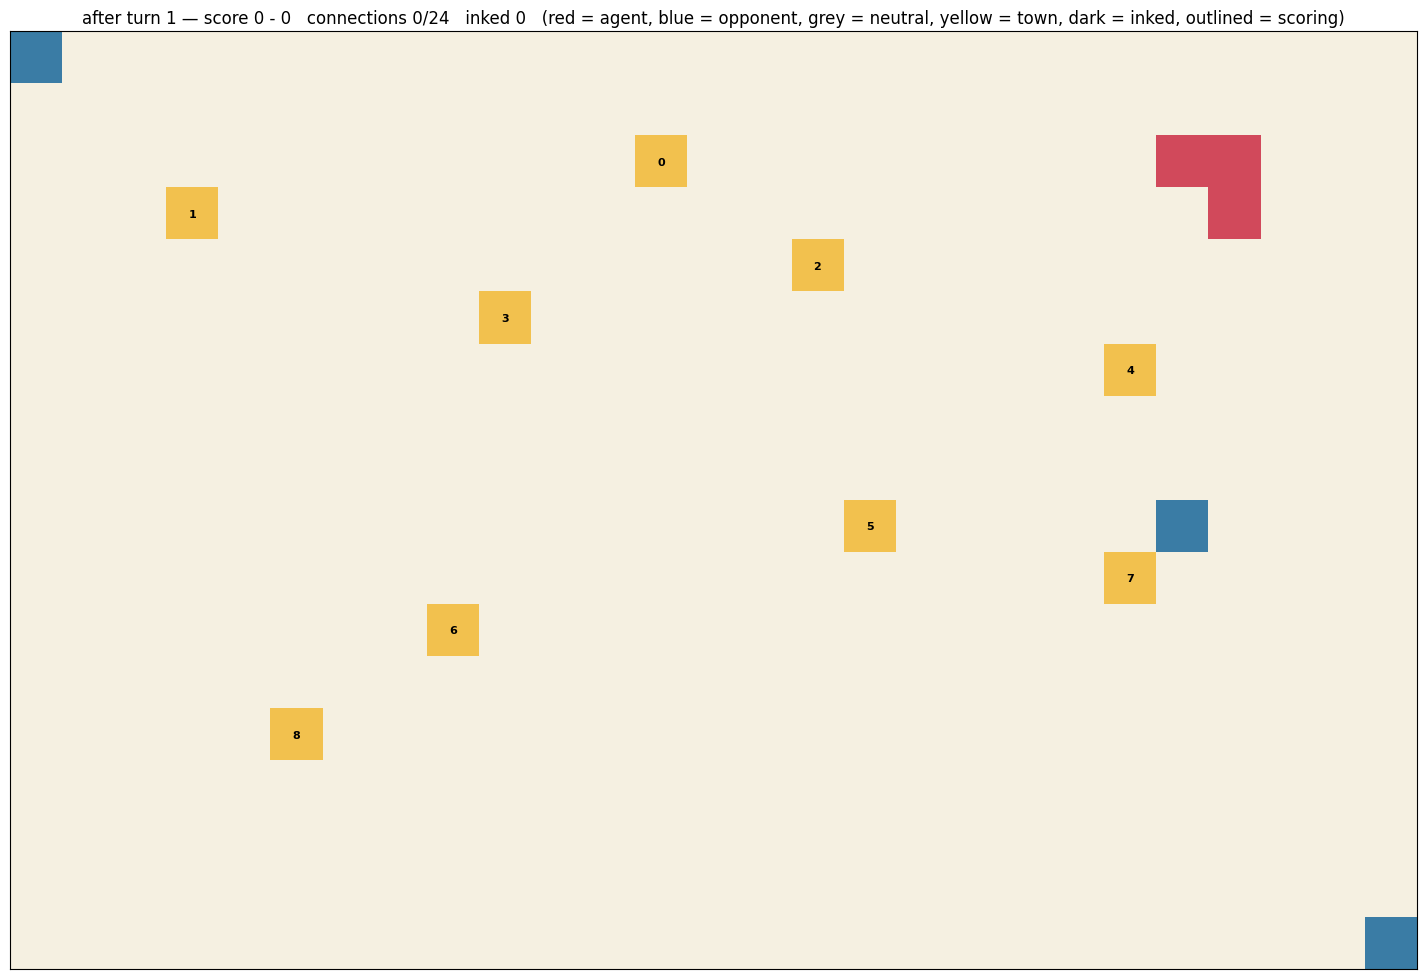

In [17]:
CHANNEL_TITLES = ["PLACE probability", "DISRUPT probability", "SKIP_DISRUPT probability"]

if step_sim.is_game_over():
    print(f"Game over. Final score: {step_sim.game_state.scores}. Re-run the cell above to restart.")
else:
    turn = step_sim.game_state.turn
    decision = 0
    while not step_sim.is_game_over() and step_sim.game_state.turn == turn:
        decision += 1
        action, probs, value, (channel, row, col) = greedy_action(model, step_sim, EPSILON, step_rng)

        n_ch = probs.shape[0]
        chosen = np.zeros(probs.shape[1:]); chosen[row, col] = 1.0
        fig, axes = plt.subplots(1, n_ch + 1, figsize=(5.2 * (n_ch + 1), 4.2))
        for i in range(n_ch):
            im = axes[i].imshow(probs[i], cmap="magma", vmin=0)
            axes[i].set_title(f"{CHANNEL_TITLES[i]}  (p={probs[i].sum():.2f})")
            axes[i].axis("off"); fig.colorbar(im, ax=axes[i], fraction=0.046)
        axes[-1].imshow(chosen, cmap="magma", vmin=0, vmax=1)
        axes[-1].set_title(f"chosen: {action[0]} {action[1]},{action[2]}"); axes[-1].axis("off")
        fig.suptitle(f"turn {turn} decision {decision} | value estimate {value:+.2f} "
                     f"| scores {step_sim.game_state.scores}")
        plt.tight_layout(); plt.show()

        step_sim.apply(action)

    gs = step_sim.game_state
    print(f"Turn {gs.turn}/{gs.max_turns} | score {gs.scores[0]} - {gs.scores[1]} | "
          f"connections {sum(len(t.paths) for t in gs.towns)} | "
          f"inked {sum(1 for z in gs.zones if z.inked)}")
    plot_board(step_sim, title=f"after turn {gs.turn} — ")


## 5. All 28 input channels

What the network actually receives for the current position of the stepping game above — the
20x30 canvas, with the real board centered and the padding marked as off-board (inked).

The route guides (10-21) and the score gap (26) are **signed**, so they use a diverging colour
map centred on 0: a town reads -1.0 in its own guide channel, -0.5 in the guide of a town that
wants to reach it, and the open-terrain cells between them read +1.0. A 0-to-1 colour scale
would clamp both town values onto the background and make the towns invisible.

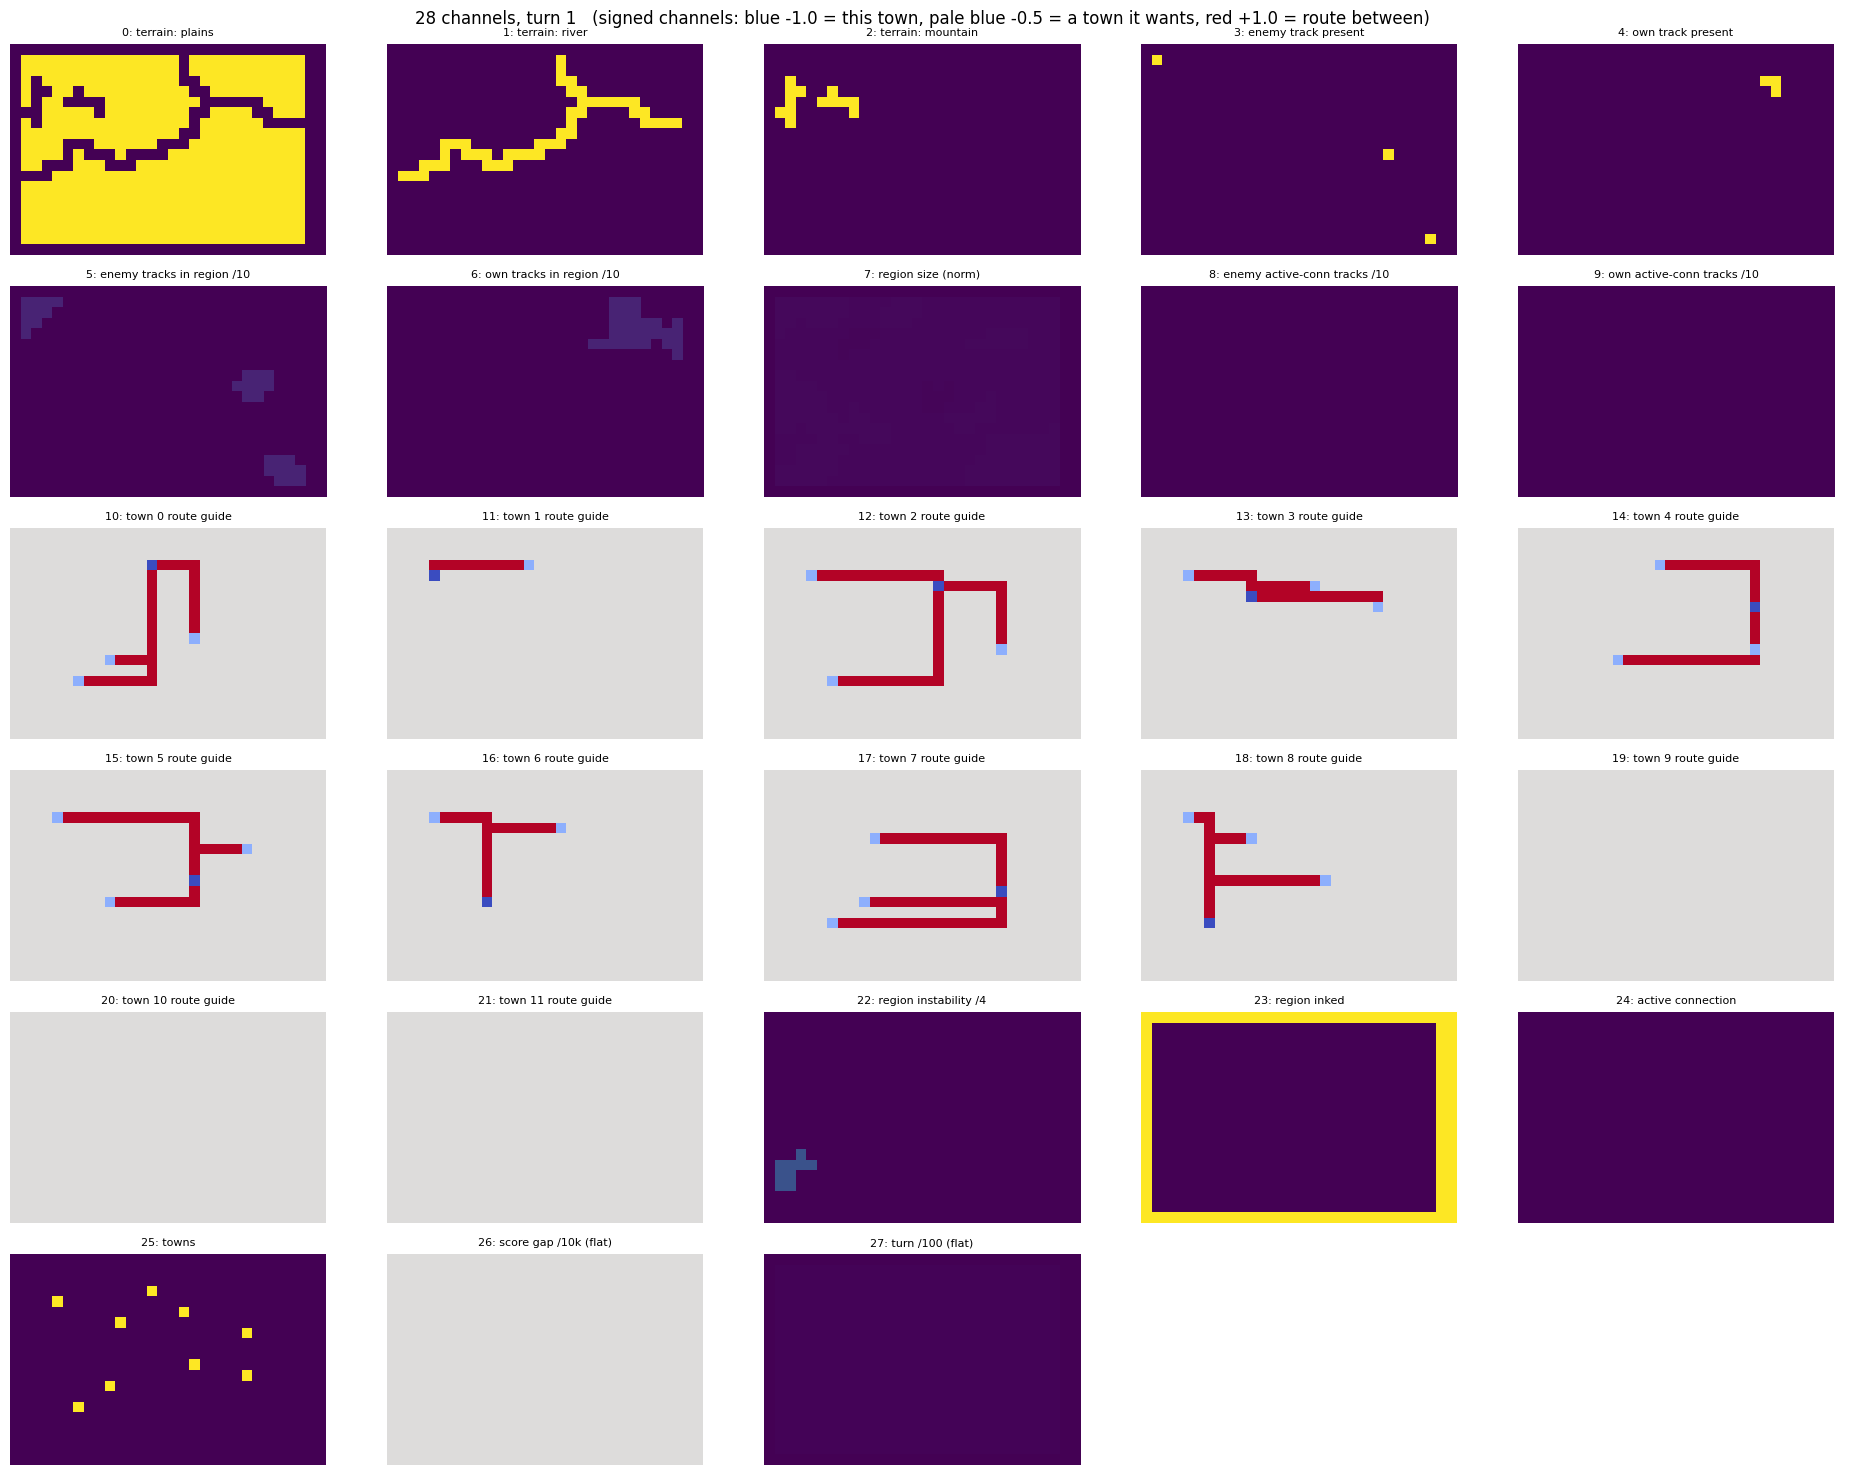

In [18]:
state = step_sim.get_encoded_state()

# Channels 10-21 (route guides) and 26 (score gap) carry NEGATIVE values - a town is -1.0 in its
# own guide and -0.5 in the guide of a town that wants it. vmin=0 clamps both to the same colour
# as the 0 background, which hides every town, so signed channels get a diverging map about 0.
_signed = set(range(GameState.TOWN_CHANNEL_START,
                    GameState.TOWN_CHANNEL_START + GameState.NUM_TOWN_CHANNELS))
_signed.add(GameState.SCORE_DIFF_CHANNEL)
_signed.update({GameState.DERIVED_CHANNEL_START + 3, GameState.DERIVED_CHANNEL_START + 4})  # tanh gaps

n_channels, ncols = GameState.NUM_CHANNELS, 5
nrows = (n_channels + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(19, 2.5 * nrows))
for i, ax in enumerate(axes.flat):
    ax.axis("off")
    if i >= n_channels:
        continue
    signed = i in _signed
    ax.imshow(state[i], cmap="coolwarm" if signed else "viridis",
              vmin=-1.0 if signed else 0.0, vmax=1.0)
    ax.set_title(f"{i}: {CHANNEL_NAMES[i]}", fontsize=8)
fig.suptitle(f"{n_channels} channels, turn {step_sim.game_state.turn}   "
             f"(signed channels: blue -1.0 = this town, pale blue -0.5 = a town it wants, "
             f"red +1.0 = route between)", fontsize=12)
plt.tight_layout(); plt.show()
